In [ ]:
# rutas del proyecto (ver modules/paths.py)
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from modules.paths import RAW, PROC, OUT


# Gráficas de `ins_data.csv`

Posición y orientación del INS.
Columnas: `date`, `ref_id`, `pos_x`, `pos_y`, `pos_z`, `yaw`.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = PROC / "2026-08-18/test3/ins_data_prueba_50.csv"
df = pd.read_csv(file_path, parse_dates=['date'])
print(f"{len(df)} filas | {df['date'].min()} -> {df['date'].max()}")
print('ref_id:', df['ref_id'].unique())
df.head()

14207 filas | 2026-08-18 13:02:31 -> 2026-08-18 13:27:08
ref_id: [13 12 11]


,date,ref_id,pos_x,pos_y,pos_z,yaw
0,2026-08-18 13:02:31,13,-33069,1719,-9884,-1285
1,2026-08-18 13:02:31,13,-33069,1719,-9884,-1285
2,2026-08-18 13:02:31,13,-33069,1719,-9884,-1284
3,2026-08-18 13:02:31,13,-33069,1719,-9884,-1284
4,2026-08-18 13:02:31,13,-33069,1719,-9884,-1283


In [8]:
df[['pos_x', 'pos_y', 'pos_z', 'yaw']].describe()

,pos_x,pos_y,pos_z,yaw
count,14207.000000,14207.000000,14207.000000,14207.000000
mean,3595.766805,-1248.428169,-15287.928204,4404.866685
std,54942.472833,13465.992900,17541.892813,9259.579469
min,-153150.000000,-52945.000000,-86257.000000,-17921.000000
25%,-16966.500000,-7050.000000,-15222.000000,-1173.000000
50%,-2157.000000,-946.000000,-9920.000000,6144.000000
75%,49277.000000,4924.000000,-4664.000000,12665.500000
max,128560.000000,38697.000000,1551.000000,17986.000000


In [ ]:
df.to_csv(file_path, index=True)

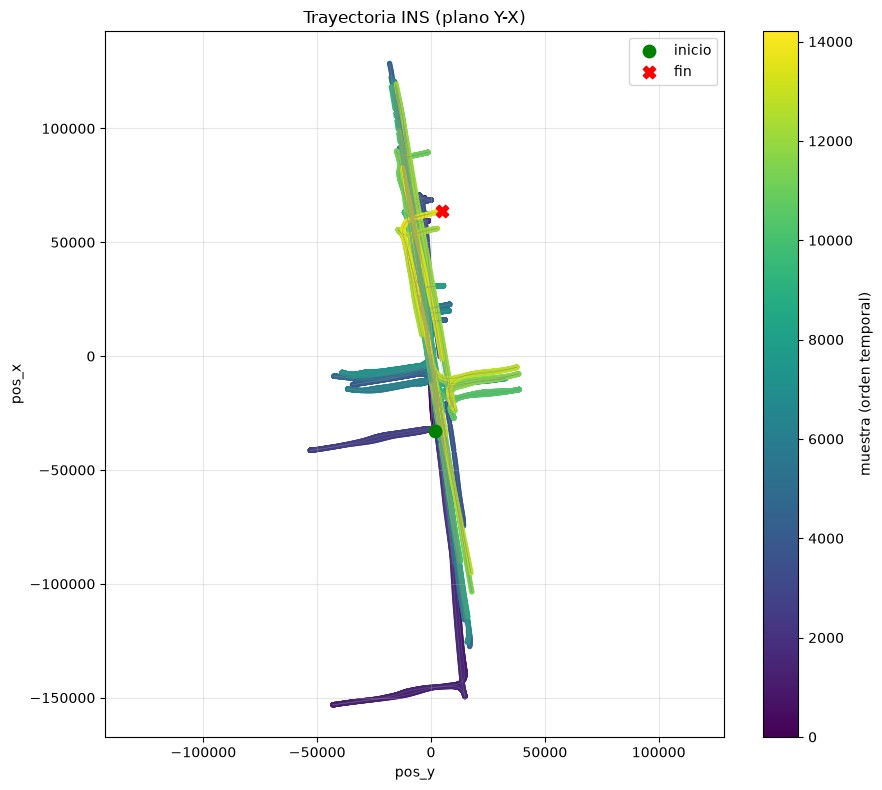

In [10]:
# Trayectoria en el plano X-Y (coloreada por tiempo)
fig, ax = plt.subplots(figsize=(9, 8))
sc = ax.scatter(df['pos_y'], df['pos_x'], c=df.index, cmap='viridis', s=8)
ax.plot(df['pos_y'], df['pos_x'], color='gray', linewidth=0.4, alpha=0.5)
ax.scatter(df['pos_y'].iloc[0], df['pos_x'].iloc[0], color='green', s=80, marker='o', label='inicio', zorder=5)
ax.scatter(df['pos_y'].iloc[-1], df['pos_x'].iloc[-1], color='red', s=80, marker='X', label='fin', zorder=5)
ax.set_xlabel('pos_y')
ax.set_ylabel('pos_x')
ax.set_title('Trayectoria INS (plano Y-X)')
ax.set_aspect('equal', adjustable='datalim')
ax.legend()
ax.grid(True, alpha=0.3)
fig.colorbar(sc, ax=ax, label='muestra (orden temporal)')
plt.tight_layout()
plt.show()

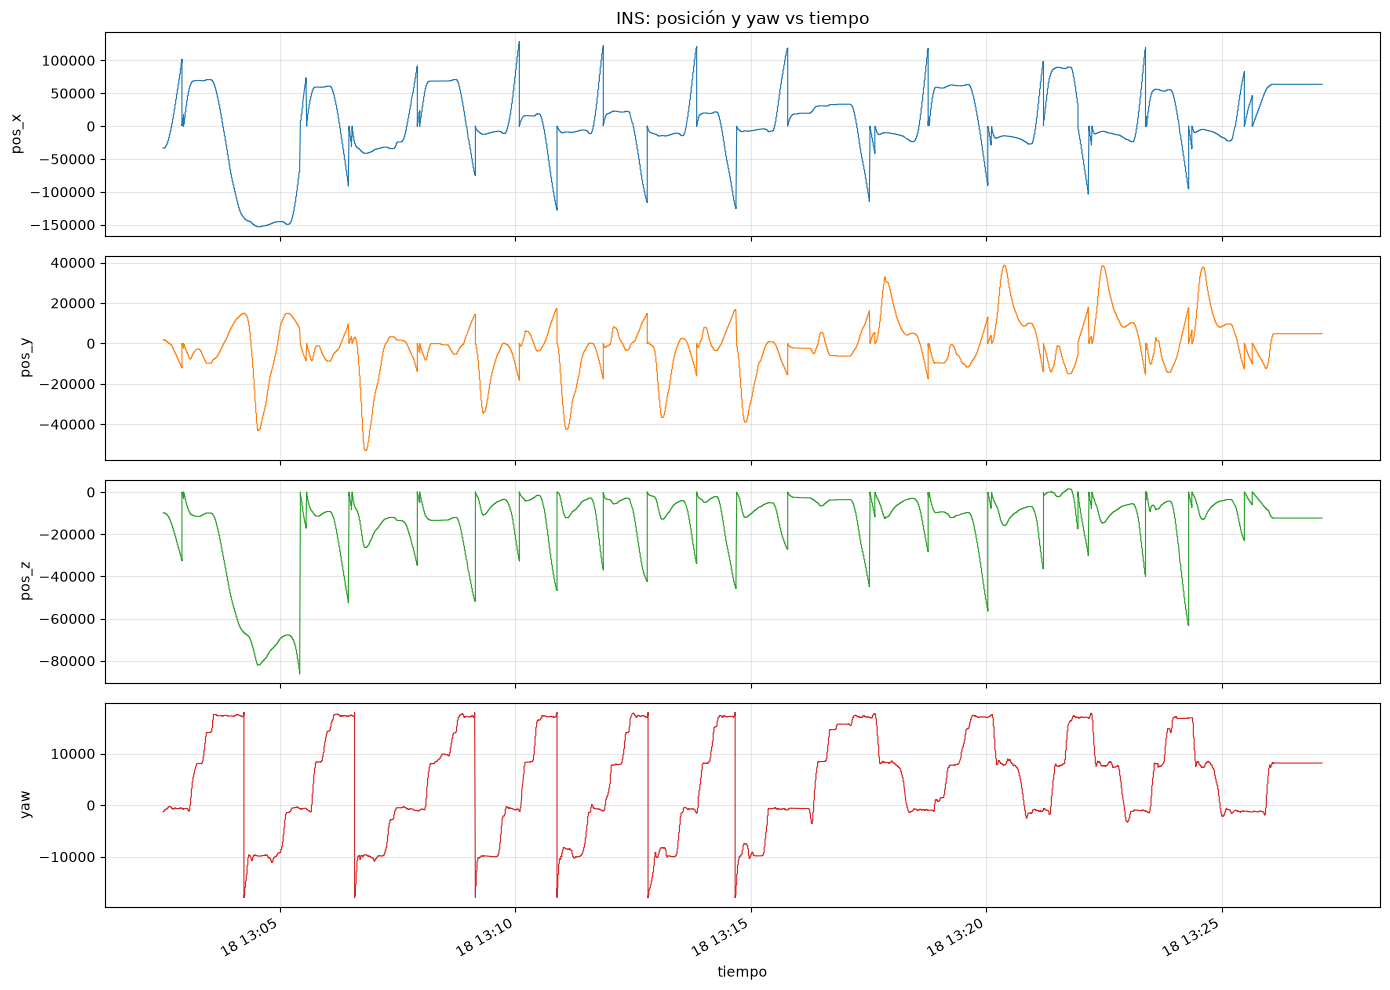

In [11]:
# Series temporales de cada componente
cols = ['pos_x', 'pos_y', 'pos_z', 'yaw']
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
fig, axes = plt.subplots(len(cols), 1, figsize=(14, 10), sharex=True)
for ax, col, c in zip(axes, cols, colors):
    ax.plot(df['date'], df[col], color=c, linewidth=0.8)
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)
axes[0].set_title('INS: posición y yaw vs tiempo')
axes[-1].set_xlabel('tiempo')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

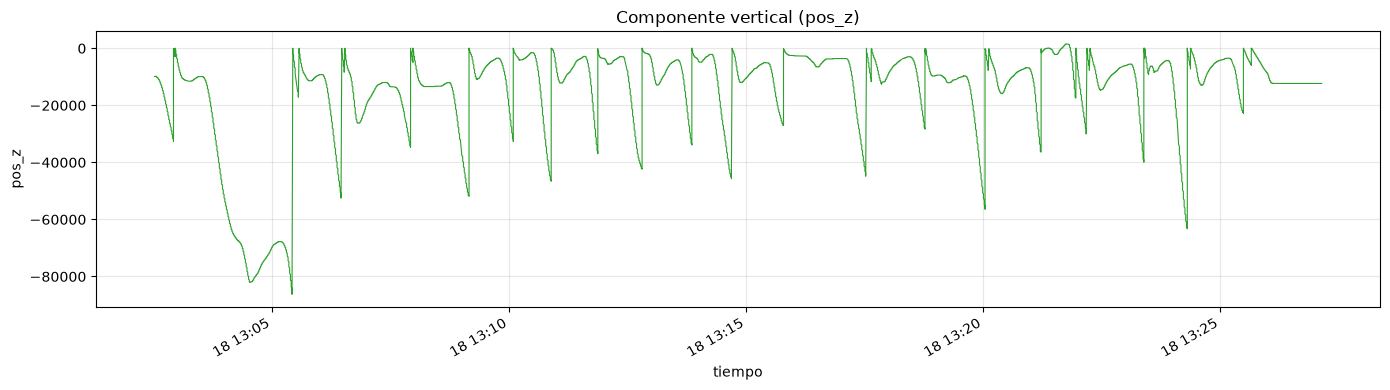

In [12]:
# Altura (pos_z) vs tiempo, en detalle
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['date'], df['pos_z'], color='tab:green', linewidth=0.8)
ax.set_xlabel('tiempo')
ax.set_ylabel('pos_z')
ax.set_title('Componente vertical (pos_z)')
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()